In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
from torch.cuda.amp import autocast,GradScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(5463)

In [3]:
dev=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
def data(n=65453):
    x=torch.randn(n,1,device=dev)*2
    y=x**2+torch.randn_like(x)*0.1
    return x,y

In [6]:
xt,yt=data()

In [7]:
dl=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt,yt),batch_size=512,shuffle=True)

In [8]:
class Mlp(nn.Module):
    def __init__(self,h=128,nla=8):
        super().__init__()
        lay=[]
        lay.append(nn.Linear(1,h))
        for _ in range(nla-1):
            lay.append(nn.Linear(h,h))
            lay.append(nn.ReLU())
        lay.append(nn.Linear(h,1))
        self.net=nn.Sequential(*lay)
    def forward(self,x):
        return self.net(x)

In [9]:
mod=Mlp().to(dev)

In [10]:
mod

Mlp(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=128, bias=True)
    (12): ReLU()
    (13): Linear(in_features=128, out_features=128, bias=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [28]:
def train_one_epoch(model, optimizer, dataloader, scaler=None, use_autocast=True, dtype=torch.float16):
    model.train()
    total_loss = 0.0
    zero_grad_count_fp16 = 0      # NEW: count in low precision
    total_grad_elements = 0
    all_grad_norms = []
    
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        
        if use_autocast:
            with torch.autocast(device_type='cuda', dtype=dtype):
                output = model(batch_x)
                loss = nn.MSELoss()(output, batch_y)
        else:
            output = model(batch_x)
            loss = nn.MSELoss()(output, batch_y)
        
        # Backward
        if scaler is not None:
            scaler.scale(loss).backward()
            # === Inspect BEFORE unscaling (this is the key) ===
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        # Look at the scaled gradient in its current dtype (FP16)
                        g_fp_low = p.grad  # still scaled at this point
                        # To simulate what happened in low precision, we can cast a copy
                        g_low = g_fp_low.to(dtype) if dtype != torch.float32 else g_fp_low
                        zero_grad_count_fp16 += (g_low == 0).sum().item()
                        total_grad_elements += g_low.numel()
                        all_grad_norms.append(g_low.abs().mean().item())
            
            scaler.unscale_(optimizer)   # now unscale for optimizer
        else:
            loss.backward()
            # For non-scaled cases, inspect after backward
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        g_low = p.grad.to(dtype) if use_autocast else p.grad
                        zero_grad_count_fp16 += (g_low == 0).sum().item()
                        total_grad_elements += g_low.numel()
        
        # Optimizer step
        if scaler is not None:
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() < 1e4:   # optional debug
                print(f"    Warning: scale dropped to {scaler.get_scale():.0f}")
        else:
            optimizer.step()
        
        total_loss += loss.item()
    
    zero_fraction = zero_grad_count_fp16 / total_grad_elements if total_grad_elements > 0 else 0
    avg_loss = total_loss / len(dataloader)
    
    print(f"  Avg Loss: {avg_loss:.6f} | Zero Grad Fraction (in low prec): {zero_fraction:.4%} "
          f"| Grad elements: {total_grad_elements:,}")
    
    if scaler is not None:
        print(f"    Final scale this epoch: {scaler.get_scale():.0f}")
    
    return avg_loss, zero_fraction, all_grad_norms

In [29]:
print("\n=== Experiment 1: Full FP32 (stable but slow/memory-heavy) ===")
model_fp32 = Mlp().to(dev)
optimizer = opt.AdamW(model_fp32.parameters(), lr=1e-4)  # small LR → smaller gradients

losses_fp32 = []
for epoch in range(5):  # few epochs for demo
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac, _ = train_one_epoch(
        model_fp32, optimizer, dl,
        scaler=None, use_autocast=False
    )
    losses_fp32.append(loss)


=== Experiment 1: Full FP32 (stable but slow/memory-heavy) ===
Epoch 1/5
  Avg Loss: 30.246474 | Zero Grad Fraction (in low prec): 50.0536% | Grad elements: 14,844,032
Epoch 2/5
  Avg Loss: 4.872339 | Zero Grad Fraction (in low prec): 46.4963% | Grad elements: 14,844,032
Epoch 3/5
  Avg Loss: 0.848867 | Zero Grad Fraction (in low prec): 40.9024% | Grad elements: 14,844,032
Epoch 4/5
  Avg Loss: 0.144908 | Zero Grad Fraction (in low prec): 38.1441% | Grad elements: 14,844,032
Epoch 5/5
  Avg Loss: 0.049358 | Zero Grad Fraction (in low prec): 37.7508% | Grad elements: 14,844,032


In [30]:
print("\n=== Experiment 2: FP16 + autocast BUT NO GradScaler (underflow!) ===")
model_fp16_no_scale = Mlp().to(dev)
optimizer = opt.AdamW(model_fp16_no_scale.parameters(), lr=1e-4)

losses_no_scale = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac, _ = train_one_epoch(
        model_fp16_no_scale, optimizer, dl,
        scaler=None, use_autocast=True, dtype=torch.float16
    )
    losses_no_scale.append(loss)


=== Experiment 2: FP16 + autocast BUT NO GradScaler (underflow!) ===
Epoch 1/5
  Avg Loss: 31.188593 | Zero Grad Fraction (in low prec): 49.6283% | Grad elements: 14,844,032
Epoch 2/5
  Avg Loss: 3.910693 | Zero Grad Fraction (in low prec): 45.0377% | Grad elements: 14,844,032
Epoch 3/5
  Avg Loss: 0.687370 | Zero Grad Fraction (in low prec): 41.9369% | Grad elements: 14,844,032
Epoch 4/5
  Avg Loss: 0.121966 | Zero Grad Fraction (in low prec): 38.4380% | Grad elements: 14,844,032
Epoch 5/5
  Avg Loss: 0.047646 | Zero Grad Fraction (in low prec): 37.9378% | Grad elements: 14,844,032


In [31]:
print("\n=== Experiment 3: FP16 + autocast + GradScaler (correct way) ===")
model_fp16 = Mlp().to(dev)
optimizer = opt.AdamW(model_fp16.parameters(), lr=1e-4)
scaler = GradScaler(init_scale=2.**15)  # you can tune initial scale

losses_fp16 = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac, _ = train_one_epoch(
        model_fp16, optimizer, dl,
        scaler=scaler, use_autocast=True, dtype=torch.float16
    )
    losses_fp16.append(loss)


=== Experiment 3: FP16 + autocast + GradScaler (correct way) ===
Epoch 1/5


/tmp/ipykernel_55/1040657850.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=2.**15)  # you can tune initial scale


  Avg Loss: 30.682289 | Zero Grad Fraction (in low prec): 51.5781% | Grad elements: 14,844,032
    Final scale this epoch: 4096
Epoch 2/5
  Avg Loss: 3.732650 | Zero Grad Fraction (in low prec): 46.0420% | Grad elements: 14,844,032
    Final scale this epoch: 4096
Epoch 3/5
  Avg Loss: 0.580883 | Zero Grad Fraction (in low prec): 40.6872% | Grad elements: 14,844,032
    Final scale this epoch: 4096
Epoch 4/5
  Avg Loss: 0.119469 | Zero Grad Fraction (in low prec): 38.0552% | Grad elements: 14,844,032
    Final scale this epoch: 4096
Epoch 5/5
  Avg Loss: 0.048399 | Zero Grad Fraction (in low prec): 37.9396% | Grad elements: 14,844,032
    Final scale this epoch: 4096


In [32]:
print("\n=== Experiment 4: BF16 (wide range, usually no scaling required) ===")
model_bf16 = Mlp().to(dev)
optimizer = opt.AdamW(model_bf16.parameters(), lr=1e-4)

losses_bf16 = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac, _ = train_one_epoch(
        model_bf16, optimizer, dl,
        scaler=None, use_autocast=True, dtype=torch.bfloat16   # note: bfloat16
    )
    losses_bf16.append(loss)


=== Experiment 4: BF16 (wide range, usually no scaling required) ===
Epoch 1/5
  Avg Loss: 28.314071 | Zero Grad Fraction (in low prec): 50.3189% | Grad elements: 14,844,032
Epoch 2/5
  Avg Loss: 4.178724 | Zero Grad Fraction (in low prec): 46.1332% | Grad elements: 14,844,032
Epoch 3/5
  Avg Loss: 0.705001 | Zero Grad Fraction (in low prec): 41.3848% | Grad elements: 14,844,032
Epoch 4/5
  Avg Loss: 0.124150 | Zero Grad Fraction (in low prec): 38.8155% | Grad elements: 14,844,032
Epoch 5/5
  Avg Loss: 0.046198 | Zero Grad Fraction (in low prec): 38.5254% | Grad elements: 14,844,032



=== Plotting Results ===


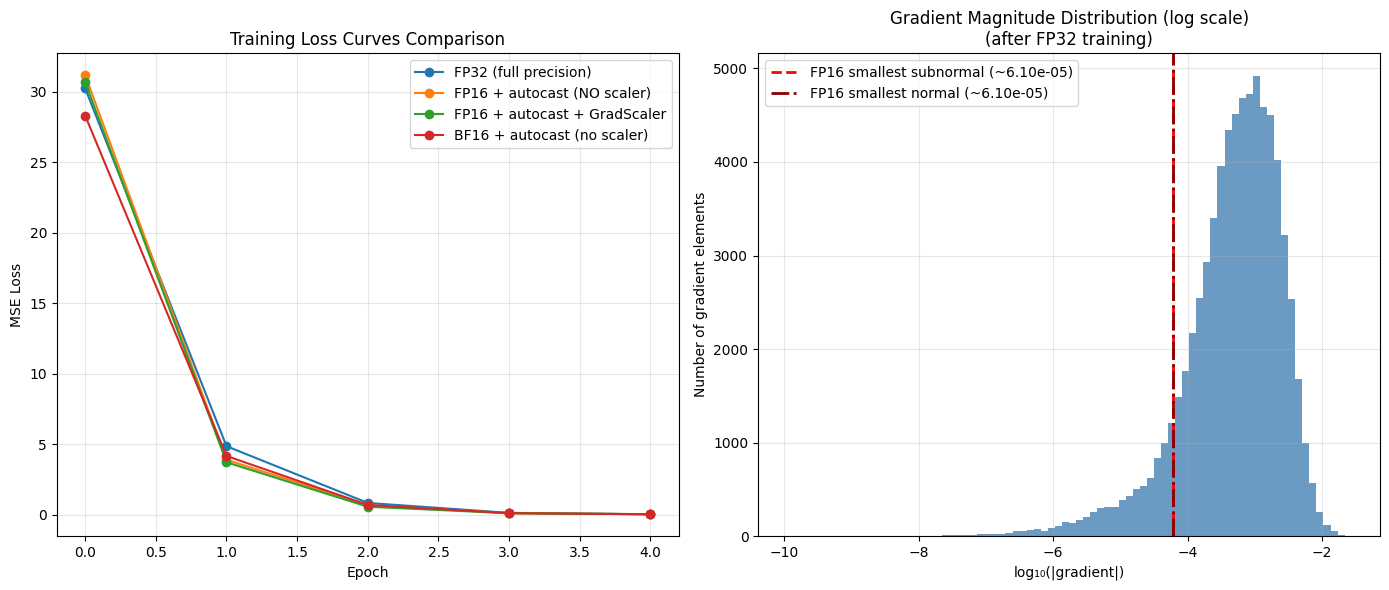

Total gradient elements: 115,969
Gradients smaller than FP16 tiny (6.10e-05): 51,635  (44.525%)
Mean |grad|: 7.11e-04
Max  |grad|: 2.75e-02


In [33]:
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Plotting Results ===")

plt.figure(figsize=(14, 6))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(losses_fp32, label='FP32 (full precision)', marker='o')
plt.plot(losses_no_scale, label='FP16 + autocast (NO scaler)', marker='o')
plt.plot(losses_fp16, label='FP16 + autocast + GradScaler', marker='o')
plt.plot(losses_bf16, label='BF16 + autocast (no scaler)', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# === Fixed Gradient Histogram ===
plt.subplot(1, 2, 2)

# Re-compute gradients properly on one of the trained models (use FP32 version)
model_fp32.train()                    # Important: switch back to train mode
model_fp32.zero_grad()                # Clear any old gradients

# Forward + loss (NO torch.no_grad!)
output = model_fp32(xt[:512])
loss = nn.MSELoss()(output, yt[:512])

loss.backward()                       # Now this will work

# Collect absolute gradient values from all parameters
grad_values = []
for name, param in model_fp32.named_parameters():
    if param.grad is not None:
        grad_values.append(param.grad.abs().view(-1).cpu().numpy())

all_grads = np.concatenate(grad_values)

# Plot histogram on log scale
valid_grads = all_grads[all_grads > 1e-40]   # avoid log(0)
plt.hist(np.log10(valid_grads), bins=80, alpha=0.8, color='steelblue')

# Mark important FP16 thresholds
fp16_tiny = torch.finfo(torch.float16).tiny
fp16_smallest_normal = torch.finfo(torch.float16).smallest_normal

plt.axvline(np.log10(fp16_tiny), color='red', linestyle='--', linewidth=2,
            label=f'FP16 smallest subnormal (~{fp16_tiny:.2e})')
plt.axvline(np.log10(fp16_smallest_normal), color='darkred', linestyle='-.', linewidth=2,
            label=f'FP16 smallest normal (~{fp16_smallest_normal:.2e})')

plt.xlabel('log₁₀(|gradient|)')
plt.ylabel('Number of gradient elements')
plt.title('Gradient Magnitude Distribution (log scale)\n(after FP32 training)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some useful statistics
print(f"Total gradient elements: {len(all_grads):,}")
print(f"Gradients smaller than FP16 tiny ({fp16_tiny:.2e}): "
      f"{(all_grads < fp16_tiny).sum():,}  ({(all_grads < fp16_tiny).mean():.3%})")
print(f"Mean |grad|: {all_grads.mean():.2e}")
print(f"Max  |grad|: {all_grads.max():.2e}")